# ISTAT TRAFFIC DATA ANALYSIS - ANALYSIS

In [1]:
# import packages
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# set style for plots
sns.set_style("whitegrid")

In the `data_preparation.ipynb` notebook, we cleaned, fixed, and joined the data from the INSTAT and SITUAS databases. Now, let's analyze this data to extract useful information about road accidents that occurred between 2001 and 2024. We will examine how these accidents changed over time and how they were affected by population growth in those cities.

In [2]:
# import data
# -> Use keep_default_na to avoid issues with misunderstood values as before (since now we know what to expect)

df_raw = pd.read_csv('data/instat_situas_traffic_accidents_data.csv', keep_default_na=False)

print(df_raw.info())
df_raw.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572700 entries, 0 to 572699
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          572700 non-null  object 
 1   FREQ              572700 non-null  object 
 2   REF_AREA          572700 non-null  int64  
 3   DATA_TYPE         572700 non-null  object 
 4   RESULT            572700 non-null  object 
 5   TIME_PERIOD       572700 non-null  int64  
 6   OBS_VALUE         572700 non-null  int64  
 7   Comune            572700 non-null  object 
 8   Provincia         572700 non-null  object 
 9   Codice Regione    572700 non-null  object 
 10  Residenti         572700 non-null  float64
 11  Superficie (Kmq)  572700 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 52.4+ MB
None


,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Comune,Provincia,Codice Regione,Residenti,Superficie (Kmq)
466744,IT1:41_983(1.0),A,79061,KILLINJ,F,2005,3,Guardavalle,CZ,Calabria,5025.0,60.2659
264216,IT1:41_983(1.0),A,30111,ROADACC,9,2001,0,Stregna,UD,Friuli-Venezia Giulia,456.0,19.6615
291986,IT1:41_983(1.0),A,41017,KILLINJ,M,2009,0,Frontino,PU,Marche,297.0,10.3672
434866,IT1:41_983(1.0),A,73016,KILLINJ,F,2020,0,Monteiasi,TA,Puglia,5394.0,9.7460
284575,IT1:41_983(1.0),A,37044,ROADACC,9,2011,18,Monzuno,BO,Emilia-Romagna,6340.0,65.0081
153672,IT1:41_983(1.0),A,17037,KILLINJ,F,2010,36,Capriano del Colle,BS,Lombardia,4481.0,13.9676
44204,IT1:41_983(1.0),A,4135,ROADACC,9,2002,0,Montaldo Roero,CN,Piemonte,882.0,11.8403
397961,IT1:41_983(1.0),A,65149,ROADACC,9,2003,2,Torre Orsaia,SA,Campania,2353.0,21.0329
159045,IT1:41_983(1.0),A,17112,KILLINJ,F,2001,3,Monticelli Brusati,BS,Lombardia,3620.0,10.8908
400169,IT1:41_983(1.0),A,66022,KILLINJ,M,2022,0,Caporciano,AQ,Abruzzo,202.0,18.6151


Let's rename some columns to help us with the analysis

In [3]:
# selecting only useful columns:
features_analysis = df_raw.columns[3:]
df = df_raw[features_analysis].copy()

df.rename(columns={
    'DATA_TYPE': 'Accident Category',
    'RESULT': 'Type',
    'TIME_PERIOD': 'Year',
    'OBS_VALUE': 'Value',
    'Comune': 'City',
    'Provincia': 'Province',
    'Codice Regione': 'Region',
    'Residenti': 'Residents',
    'Superficie (Kmq)': 'Area (km2)'
    },
    inplace=True
)

df.sample(5)

,Accident Category,Type,Year,Value,City,Province,Region,Residents,Area (km2)
360773,KILLINJ,F,2021,18,Casapulla,CE,Campania,8374.0,2.9225
374350,ROADACC,9,2002,1,Comiziano,NA,Campania,1805.0,2.4493
13613,KILLINJ,F,2009,3,Piobesi Torinese,TO,Piemonte,3641.0,19.6488
238419,KILLINJ,F,2004,202,Mogliano Veneto,TV,Veneto,27236.0,46.2562
368795,KILLINJ,M,2024,0,Faicchio,BN,Campania,3204.0,43.9892


Working with this type of data structure can be difficult. It would be much easier if we had only one row (record) for each city and year instead of three.    
To do that we can pivot the table to create three new columns for fatalities, injuries, and collisions with the respective values.  
By doing this, we can neglect the columns for `Accident Category`. Meanwhile, the values for `Type` are transformed into new columns.

In [4]:
# PIVOT TABLE

df_pivot = df.pivot_table(
    index=['Year', 'City', 'Province', 'Region', 'Residents', 'Area (km2)'],
    columns='Type',
    values='Value',
    fill_value=0,
).reset_index()

# Rename columns for clarity
df_pivot = df_pivot.rename(columns={
    '9': 'Collisions',
    'F': 'Injuries',
    'M': 'Fatalities'
    }
)

df_pivot

Type,Year,City,Province,Region,Residents,Area (km2),Collisions,Injuries,Fatalities
0,2001,Abano Terme,PD,Veneto,18177.0,21.4376,79.0,105.0,0.0
1,2001,Abbadia Cerreto,LO,Lombardia,275.0,6.1986,1.0,2.0,0.0
2,2001,Abbadia Lariana,LC,Lombardia,3146.0,16.6703,28.0,44.0,0.0
3,2001,Abbadia San Salvatore,SI,Toscana,6824.0,58.9933,24.0,34.0,2.0
4,2001,Abbasanta,OR,Sardegna,2814.0,39.8469,12.0,15.0,1.0
...,...,...,...,...,...,...,...,...,...
190895,2024,Zubiena,BI,Piemonte,1125.0,12.4739,6.0,6.0,0.0
190896,2024,Zuccarello,SV,Liguria,279.0,10.8070,4.0,4.0,0.0
190897,2024,Zugliano,VI,Veneto,6901.0,13.7300,3.0,4.0,0.0
190898,2024,Zumpano,CS,Calabria,2603.0,8.0838,5.0,9.0,1.0


As you can see, the rows are now 1/3 the size of the original. We can now proceed by calculating some useful metrics for our analysis:
1) **Total Accidents:** total number of accidents 
2) **Harmful Accidents:** total number of accidents that caused deaths or injuries
3) **Severity Index:** ratio of fatal (M) and serious (F) accidents divided by the total. This metric helps us to calculate how much dangerous the roads are
4) **Fatality Rate:** ratio of fatal accidents divided by the total
5) **Per-Capita Accident Rate (per 10,000 residents):** ratio of accidents per 10,000 residents. This helps us avoid biased values for cities with large populations and it also indicates the number of accidents for every 10,000 inhabitants.
6) **Collision Density:** ratio of total accidents divided by the area (km2)

In [5]:
# check min values for division
print(df_pivot['Area (km2)'].min(), df_pivot['Residents'].max())

0.1206 2820219.0


In [6]:
# 1) Total Accidents
df_pivot['Total_Accidents'] = df_pivot['Collisions'] + df_pivot['Injuries'] + df_pivot['Fatalities']

# 2) Harmful Accidents (M + F)
df_pivot['Harmful_Accidents'] = df_pivot['Fatalities'] + df_pivot['Injuries']

# 3) Severity Index (where condition to taking into account possible division by zero)
df_pivot['Severity_index'] = np.where(df_pivot['Total_Accidents'] > 0, df_pivot['Harmful_Accidents'] / df_pivot['Total_Accidents'], 0,)

# 4) Fatality Rate
df_pivot['Fatality_Rate'] = np.where(df_pivot['Total_Accidents'] > 0, df_pivot['Fatalities'] / df_pivot['Total_Accidents'], 0,)

# 5) Per-Capita Accidents Rate
df_pivot['Per_Capita_Accidents_Rate'] = (df_pivot['Total_Accidents'] / df_pivot['Residents']) * 1e4

# 6) Collision Density
df_pivot['Collision_Density'] = df_pivot['Total_Accidents'] / df_pivot['Area (km2)']

df_pivot


Type,Year,City,Province,Region,Residents,Area (km2),Collisions,Injuries,Fatalities,Total_Accidents,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
0,2001,Abano Terme,PD,Veneto,18177.0,21.4376,79.0,105.0,0.0,184.0,105.0,0.570652,0.000000,101.226825,8.583050
1,2001,Abbadia Cerreto,LO,Lombardia,275.0,6.1986,1.0,2.0,0.0,3.0,2.0,0.666667,0.000000,109.090909,0.483980
2,2001,Abbadia Lariana,LC,Lombardia,3146.0,16.6703,28.0,44.0,0.0,72.0,44.0,0.611111,0.000000,228.862047,4.319058
3,2001,Abbadia San Salvatore,SI,Toscana,6824.0,58.9933,24.0,34.0,2.0,60.0,36.0,0.600000,0.033333,87.924971,1.017065
4,2001,Abbasanta,OR,Sardegna,2814.0,39.8469,12.0,15.0,1.0,28.0,16.0,0.571429,0.035714,99.502488,0.702690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190895,2024,Zubiena,BI,Piemonte,1125.0,12.4739,6.0,6.0,0.0,12.0,6.0,0.500000,0.000000,106.666667,0.962009
190896,2024,Zuccarello,SV,Liguria,279.0,10.8070,4.0,4.0,0.0,8.0,4.0,0.500000,0.000000,286.738351,0.740261
190897,2024,Zugliano,VI,Veneto,6901.0,13.7300,3.0,4.0,0.0,7.0,4.0,0.571429,0.000000,10.143457,0.509832
190898,2024,Zumpano,CS,Calabria,2603.0,8.0838,5.0,9.0,1.0,15.0,10.0,0.666667,0.066667,57.625816,1.855563


Let's also create another data frame that takes the entire time span and sums all the accident values. For the area we will take the mean values across the years since Mmnicipal boundaries rarely change in Italy.  
On the other hand, for the number of residents, it is better to take the total number across the time span, since we are summing the total number of accidents. If we need to calculate the per capita rate, it is more correct to calculate it by dividing the total number of accidents by the total number of residents.

In [7]:
df_pivot_24y = df_pivot.groupby(['City', 'Province', 'Region']).agg(
                                                                    Sum_Residents_Years=('Residents', 'sum'),
                                                                    Mean_Area_km2=('Area (km2)', 'mean'),
                                                                    Total_Collisions=('Collisions', 'sum'),
                                                                    Total_Fatalities=('Fatalities', 'sum'),
                                                                    Total_Injuries=('Injuries', 'sum'),
                                                                    Total_Accidents=('Total_Accidents', 'sum'),
                                                                    Years_Recorded=('Year', 'count'),
                                                                    ).reset_index()


# calculcate again the metrics
# 2) Harmful Accidents (M + F)
df_pivot_24y['Harmful_Accidents'] = df_pivot_24y['Total_Fatalities'] + df_pivot_24y['Total_Injuries']

# 3) Severity Index (where condition to taking into account possible division by zero)
df_pivot_24y['Severity_index'] = np.where(df_pivot_24y['Total_Accidents'] > 0, df_pivot_24y['Harmful_Accidents'] / df_pivot_24y['Total_Accidents'], 0,)

# 4) Fatality Rate
df_pivot_24y['Fatality_Rate'] = np.where(df_pivot_24y['Total_Accidents'] > 0, df_pivot_24y['Total_Fatalities'] / df_pivot_24y['Total_Accidents'], 0,)

# 5) Per-Capita Accidents Rate
df_pivot_24y['Per_Capita_Accidents_Rate'] = (df_pivot_24y['Total_Accidents'] / df_pivot_24y['Sum_Residents_Years']) * 1e4

# 6) Collision Density
df_pivot_24y['Collision_Density'] = df_pivot_24y['Total_Accidents'] / df_pivot_24y['Mean_Area_km2']

df_pivot_24y

,City,Province,Region,Sum_Residents_Years,Mean_Area_km2,Total_Collisions,Total_Fatalities,Total_Injuries,Total_Accidents,Years_Recorded,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
0,Abano Terme,PD,Veneto,467889.0,21.420504,1527.0,28.0,1900.0,3455.0,24,1928.0,0.558032,0.008104,73.842300,161.294056
1,Abbadia Cerreto,LO,Lombardia,6567.0,6.198600,1.0,0.0,2.0,3.0,23,2.0,0.666667,0.000000,4.568296,0.483980
2,Abbadia Lariana,LC,Lombardia,76948.0,16.658875,729.0,12.0,1077.0,1818.0,24,1089.0,0.599010,0.006601,236.263451,109.131019
3,Abbadia San Salvatore,SI,Toscana,155734.0,58.993300,278.0,7.0,406.0,691.0,24,413.0,0.597685,0.010130,44.370529,11.713195
4,Abbasanta,OR,Sardegna,66219.0,39.846867,161.0,7.0,247.0,415.0,24,254.0,0.612048,0.016867,62.670835,10.414872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8601,Zuglio,UD,Friuli-Venezia Giulia,13688.0,18.211300,11.0,0.0,12.0,23.0,23,12.0,0.521739,0.000000,16.803039,1.262952
8602,Zumaglia,BI,Piemonte,24768.0,2.613643,17.0,0.0,20.0,37.0,23,20.0,0.540541,0.000000,14.938630,14.156483
8603,Zumpano,CS,Calabria,56745.0,8.083800,74.0,2.0,152.0,228.0,24,154.0,0.675439,0.008772,40.179752,28.204557
8604,Zungoli,AV,Campania,27058.0,19.212374,0.0,0.0,0.0,0.0,23,0.0,0.000000,0.000000,0.000000,0.000000


First, let's look at top-of-mind questions, such as which city has the most and fewest accidents. Since we can see from the above data frame that there are cities without any accidents, we will take the cities that have had zero total accidents.  
We also print the city with the highest per capita values of accidents to compare it with the city that has the highest number of accidents.

In [8]:
print(f'City with the highest total number of accidents in 24 years: {df_pivot_24y.loc[df_pivot_24y["Total_Collisions"].idxmax(), "City"]} \n')
print(f'Cities with the lowest total number of accidents in 24 years: {df_pivot_24y.loc[df_pivot_24y["Total_Collisions"] == 0, "City"].values.shape[0]}')
print(df_pivot_24y.loc[df_pivot_24y["Total_Collisions"] == 0, "City"].values)
print(f'\nCity with the highest Per-Capita Accidents Rate in 24 years: {df_pivot_24y.loc[df_pivot_24y["Per_Capita_Accidents_Rate"].idxmax(), "City"]}')

City with the highest total number of accidents in 24 years: Roma 

Cities with the lowest total number of accidents in 24 years: 70
['Armo' 'Bardello con Malgesso e Bregano' 'Bellino' 'Bidonì' 'Blello'
 'Borgomezzavalle' 'Brione' 'Canosio' 'Carbone' 'Carcoforo' 'Carpanzano'
 'Casorzo Monferrato' 'Castel di Lucio' 'Castellania Coppi'
 'Castelpizzuto' 'Chamois' 'Cirigliano' 'Collinas' 'Conca Casale'
 'Crissolo' 'Dosso del Liro' 'Escalaplano' 'Faeto' 'Falmenta' 'Fobello'
 'Gallo Matese' 'Genuri' 'Genuri' 'Genuri' 'Ginestra degli Schiavoni'
 'Guilmi' 'Igliano' 'Lecce nei Marsi' 'Leni' 'Luserna' 'Massello'
 'Montagne' 'Monte Grimano' 'Montelapiano' 'Moransengo-Tonengo' 'Ollomont'
 'Panettieri' 'Pauli Arbarei' 'Prezzo' 'Quaranti' 'Rhêmes-Notre-Dame'
 'Rima San Giuseppe' 'Rimella' 'Roccaforte Ligure' 'Roccaforte del Greco'
 'Sabbia' 'Sagama' 'Salle' 'Salza di Pinerolo' 'San Biase'
 'San Lorenzo Bellizzi' 'San Pietro in Amantea' "Sant'Anna Arresi"
 'Serole' 'Setzu' 'Seui' 'Seulo' 'Soprana' 'T

As expected, Rome has the highest number of accidents since it is the capital and has the most residents in Italy. However, if we look at the number of accidents per capita, we can see that Belforte Monferrato has the most.  
On the other hand, cities where no accidents ever occur are very small towns, and there are no medium- or large-sized cities within them.

In [9]:
# print the top 10 cities by accidents per-capita

df_pivot_24y.sort_values(by='Per_Capita_Accidents_Rate', ascending=False).reset_index(drop=True).iloc[:10]

,City,Province,Region,Sum_Residents_Years,Mean_Area_km2,Total_Collisions,Total_Fatalities,Total_Injuries,Total_Accidents,Years_Recorded,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
0,Belforte Monferrato,AL,Piemonte,11684.0,8.325800,271.0,9.0,435.0,715.0,24,444.0,0.620979,0.012587,611.947963,85.877633
1,Priero,CN,Piemonte,12264.0,19.976367,210.0,5.0,327.0,542.0,24,332.0,0.612546,0.009225,441.943901,27.132061
2,Ponte Gardena/Waidbruck,BZ,Trentino-Alto Adige/Südtirol,4791.0,2.317742,77.0,0.0,110.0,187.0,24,110.0,0.588235,0.000000,390.315174,80.681986
3,Dorio,LC,Lombardia,7705.0,11.655600,116.0,7.0,177.0,300.0,23,184.0,0.613333,0.023333,389.357560,25.738701
4,Bard,AO,Valle d'Aosta,3008.0,3.031458,42.0,6.0,67.0,115.0,24,73.0,0.634783,0.052174,382.313830,37.935537
5,Nazzano,RM,Lazio,32549.0,12.396933,435.0,12.0,776.0,1223.0,24,788.0,0.644317,0.009812,375.741190,98.653430
6,Villarboit,VC,Piemonte,10910.0,25.510900,141.0,20.0,248.0,409.0,24,268.0,0.655257,0.048900,374.885426,16.032363
7,Forte dei Marmi,LU,Toscana,181615.0,8.957700,2887.0,22.0,3857.0,6766.0,24,3879.0,0.573308,0.003252,372.546321,755.327819
8,Camerata Nuova,RM,Lazio,10429.0,40.494678,138.0,3.0,236.0,377.0,23,239.0,0.633952,0.007958,361.491993,9.309865
9,Roccavignale,SV,Liguria,17777.0,17.706642,219.0,2.0,420.0,641.0,24,422.0,0.658346,0.003120,360.578275,36.201105


In [10]:
df_pivot_24y.loc[df_pivot_24y['City'].isin(['Roma', 'Belforte Monferrato'])]

,City,Province,Region,Sum_Residents_Years,Mean_Area_km2,Total_Collisions,Total_Fatalities,Total_Injuries,Total_Accidents,Years_Recorded,Harmful_Accidents,Severity_index,Fatality_Rate,Per_Capita_Accidents_Rate,Collision_Density
629,Belforte Monferrato,AL,Piemonte,11684.0,8.325800,271.0,9.0,435.0,715.0,24,444.0,0.620979,0.012587,611.947963,85.877633
6237,Roma,RM,Lazio,64634392.0,1287.499925,390605.0,4350.0,506345.0,901300.0,24,510695.0,0.566620,0.004826,139.445885,700.038876


Even though Belforte Monferrato is much smaller than Rome, it has a higher severity index and fatality rate than Rome, and almost six times the number of accidents per capita.  
Let's have a look at some plots

### PLOTS
First, we can examine how the following metrics change over time for Rome (a large city) and Belforte Monferrato (a small town with a high accident rate): accidents per capita, severity index, fatality rate, and collision density.    
We will use a line plot, where the x-axis represents the years and the y-axis represents the values of the metric.

In [11]:
df_pivot.columns

Index(['Year', 'City', 'Province', 'Region', 'Residents', 'Area (km2)',
       'Collisions', 'Injuries', 'Fatalities', 'Total_Accidents',
       'Harmful_Accidents', 'Severity_index', 'Fatality_Rate',
       'Per_Capita_Accidents_Rate', 'Collision_Density'],
      dtype='object', name='Type')

In [15]:
example_city = ['Roma', 'Belforte Monferrato']
metrics = ['Severity_index', 'Fatality_Rate', 'Per_Capita_Accidents_Rate', 'Collision_Density']

# melt the pivot dataframe to make easier to do the plot
df_melted = df_pivot[df_pivot['City'].isin(example_city)].melt(
    id_vars=['City', 'Year'],
    value_vars=metrics,
    var_name='Metric',
    value_name='Value',
)

metric_labels = {
    'Per_Capita_Accidents_Rate': 'Accidents per 10k Residents',
    'Severity_index': 'Severity Index',
    'Fatality_Rate': 'Fatality Rate',
    'Collision_Density': 'Collision Density (per Sq Km)',
}
df_melted['Metric'] = df_melted['Metric'].map(metric_labels)

df_melted

,City,Year,Metric,Value
0,Belforte Monferrato,2001,Severity Index,0.670330
1,Roma,2001,Severity Index,0.559039
2,Belforte Monferrato,2002,Severity Index,0.600000
3,Roma,2002,Severity Index,0.559197
4,Belforte Monferrato,2003,Severity Index,0.626866
...,...,...,...,...
187,Roma,2022,Collision Density (per Sq Km),23.248945
188,Belforte Monferrato,2023,Collision Density (per Sq Km),2.762497
189,Roma,2023,Collision Density (per Sq Km),22.507593
190,Belforte Monferrato,2024,Collision Density (per Sq Km),3.002714


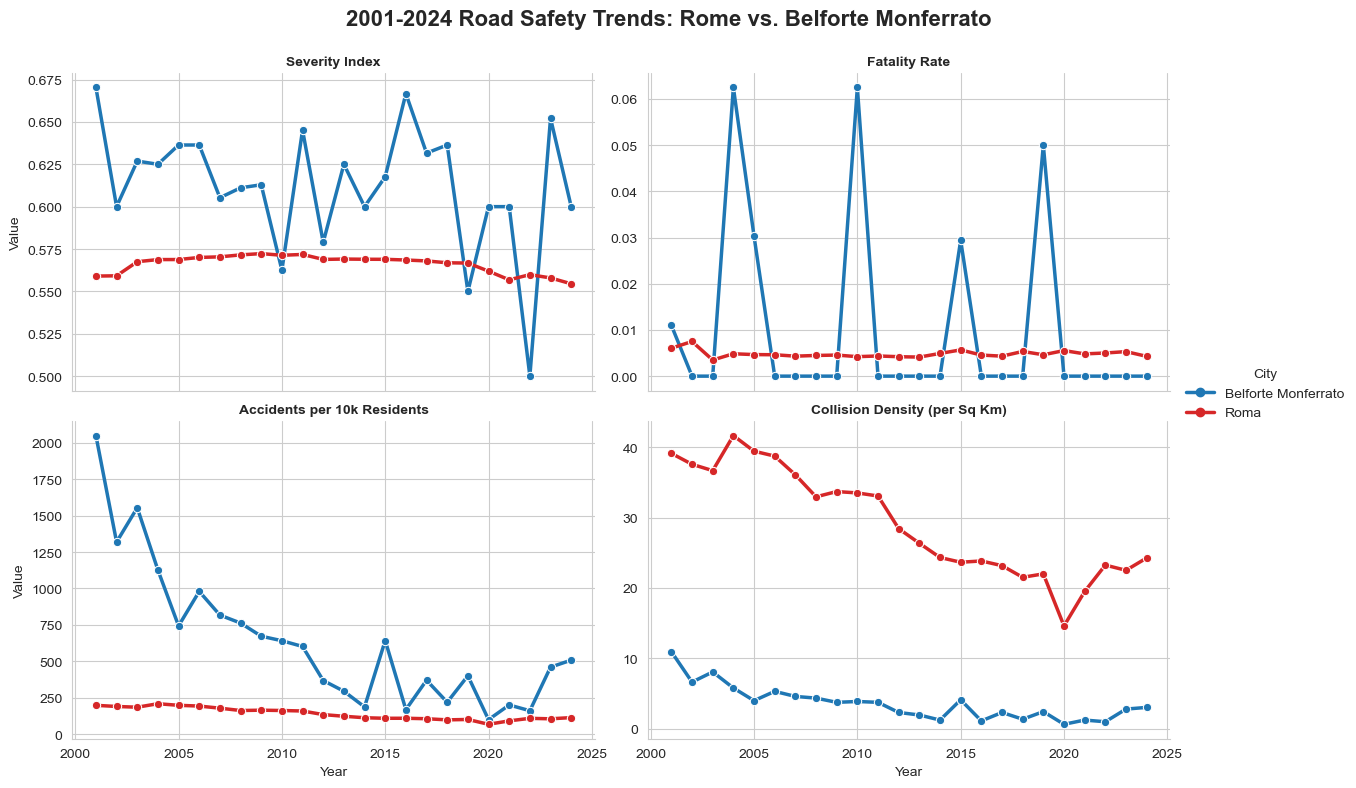

In [ ]:
# Plot FacetGrid
g = sns.relplot(
    data=df_melted,
    x='Year',
    y='Value',
    hue='City',
    col='Metric',
    col_wrap=2,
    kind='line',
    height=4,
    aspect=1.5,
    facet_kws={'sharey': False},  # each metric keeps its own Y-axis scale
    palette={'Roma': '#d62728', 'Belforte Monferrato': '#1f77b4'},
    linewidth=2.5,
    marker='o',
)

g.set_titles(col_template='{col_name}', weight='bold')
g.set_axis_labels('Year', 'Value')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('2001-2024 Road Safety Trends: Rome vs. Belforte Monferrato', fontsize=16, weight='bold')
plt.show()